# Plot types

Every mark pyplotrs can draw, grouped by what it is for, with nothing styled:
this is the default output on plain data. Use it as a menu — find the picture
you want, take the call under it.

The rules that hold across the whole vocabulary:

- **Every mark takes any iterable of numbers.** Lists, tuples, generators,
  `array.array`, NumPy arrays, pandas or polars columns.
- **Every mark accepts `label`, `color`, `alpha` and `zorder`**, and returns the
  axes, so calls chain and `legend()` picks up whatever carried a label.
- **Marks that produce a color mapping** (`scatter(c=…)`, `imshow`, `contourf`,
  `pcolormesh`, `hexbin`, `hist2d`, `matshow`) return a `Mappable`, which is
  what you hand to `fig.colorbar(...)`.
- **Draw order is call order**, unless `zorder` says otherwise.

In [1]:
import math
import random

import pyplotrs as plt

plt.set_font_family("Liberation Sans")   # reproducible renders; see the quickstart
random.seed(4)

# One set of numbers reused all the way down, so the differences between the
# panels are differences between the marks.
t = [i * 0.15 for i in range(61)]
wave = [math.sin(x) for x in t]
damped = [math.sin(x) * math.exp(-0.2 * x) for x in t]

species = ["ash", "birch", "cedar", "elm"]
counts = [12.0, 19.0, 7.5, 15.2]
counts_b = [8.0, 11.5, 12.0, 6.4]

normal = [random.gauss(0.0, 1.0) for _ in range(600)]
groups = [[random.gauss(mu, sd) for _ in range(150)]
          for mu, sd in ((0.0, 1.0), (1.8, 1.3), (-1.2, 0.8), (2.5, 1.6))]
cloud_x = [random.gauss(0.0, 1.0) for _ in range(800)]
cloud_y = [x * 0.6 + random.gauss(0.0, 0.8) for x in cloud_x]

# A 2D field, as plain nested lists: rows are y, columns are x.
NX, NY = 48, 36
gx = [-3.0 + 6.0 * j / (NX - 1) for j in range(NX)]
gy = [-2.5 + 5.0 * i / (NY - 1) for i in range(NY)]
field = [[math.sin(x) * math.cos(y) + 0.35 * math.exp(-(x * x + y * y) / 3)
          for x in gx] for y in gy]

print("data ready:", len(t), "samples,", NY, "×", NX, "field")

data ready: 61 samples, 36 × 48 field


## Lines, steps and areas

`line` is the workhorse. `step` and `stairs` are for quantities that hold a
value over an interval — a rate that changes at the boundary, a histogram you
computed yourself — and `stem` for individually meaningful samples.
`fill_between` turns a pair of curves into a band.

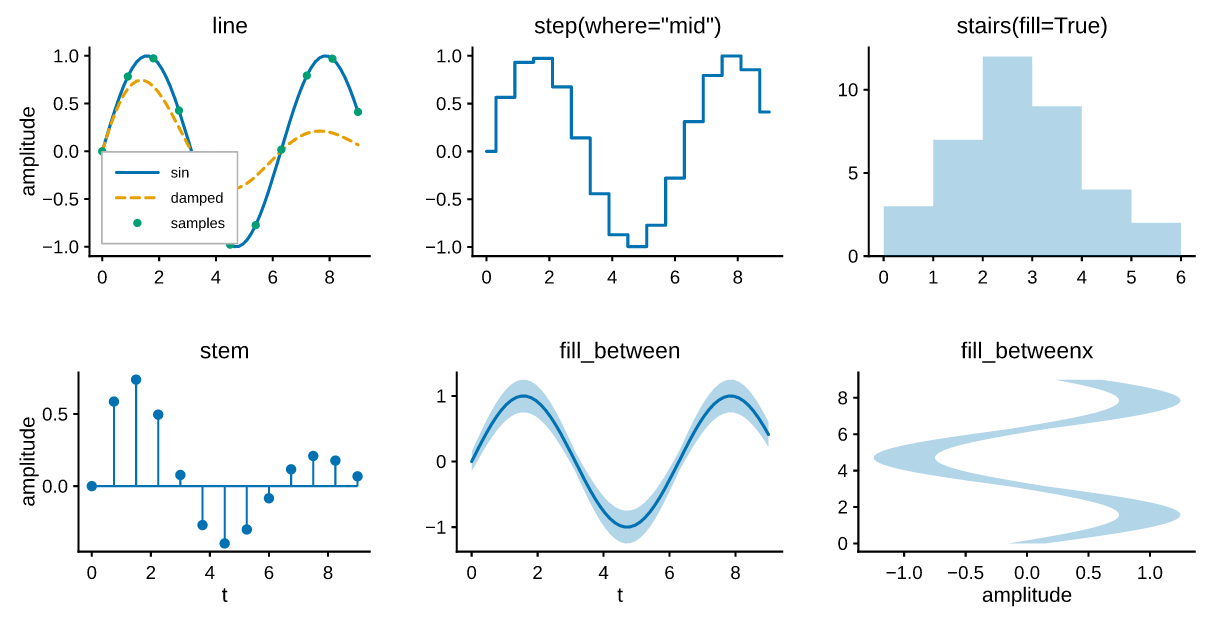

In [2]:
fig, axs = plt.subplots(2, 3, figsize=(580, 300))

axs[0][0].line(t, wave, label="sin")
axs[0][0].line(t, damped, label="damped", linestyle="dashed")
axs[0][0].line(t[::6], wave[::6], linestyle="none", marker="o", markersize=4,
               label="samples")
axs[0][0].set(title="line", ylabel="amplitude")
axs[0][0].legend(fontsize=7)

axs[0][1].step(t[::4], wave[::4], where="mid")
axs[0][1].set(title="step(where=\"mid\")")

# `stairs` takes N values and N+1 edges: the shape of an already-binned count.
axs[0][2].stairs([3, 7, 12, 9, 4, 2], [0, 1, 2, 3, 4, 5, 6], fill=True)
axs[0][2].set(title="stairs(fill=True)")

axs[1][0].stem(t[::5], damped[::5])
axs[1][0].set(title="stem", xlabel="t", ylabel="amplitude")

band = [0.15 + 0.1 * abs(y) for y in wave]
axs[1][1].fill_between(t, [y - b for y, b in zip(wave, band)],
                       [y + b for y, b in zip(wave, band)], label="±band")
axs[1][1].line(t, wave, color="C0")
axs[1][1].set(title="fill_between", xlabel="t")

axs[1][2].fill_betweenx(t, [y - b for y, b in zip(wave, band)],
                        [y + b for y, b in zip(wave, band)])
axs[1][2].set(title="fill_betweenx", xlabel="amplitude")

fig

## Bars and stacks

`bar` and `barh` take either numbers or strings for the category axis. Stacking
is `bottom=` (or `left=` for `barh`); grouping is an offset you choose, because
the offset is a layout decision and pyplotrs would rather you owned it.

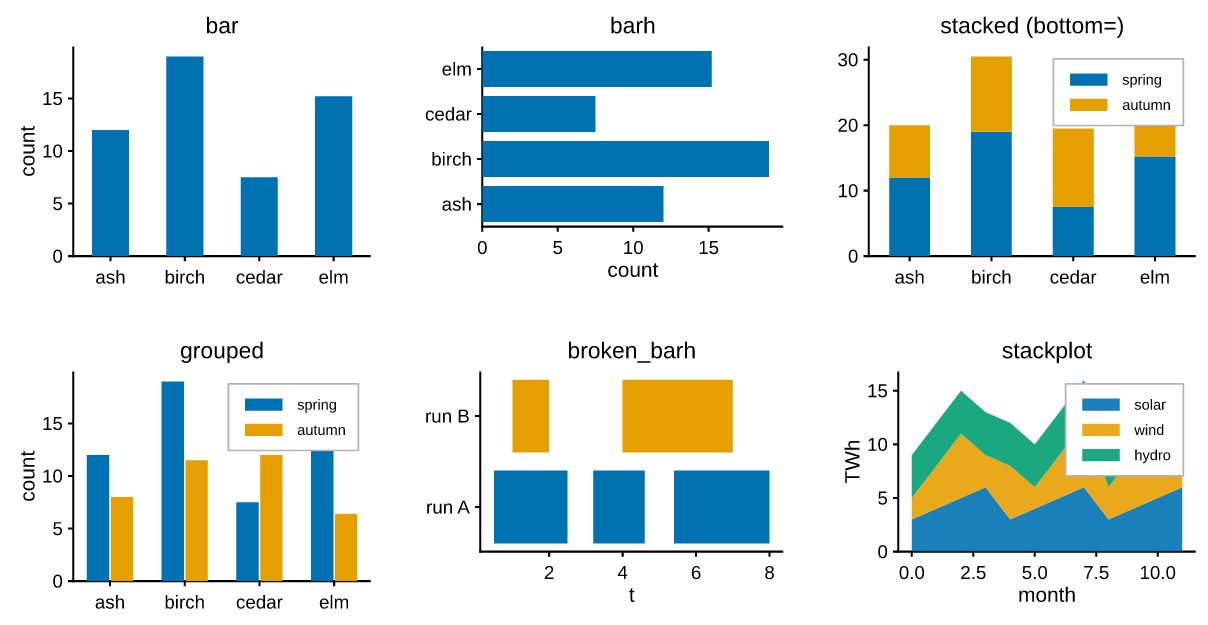

In [3]:
fig, axs = plt.subplots(2, 3, figsize=(580, 300))

axs[0][0].bar(species, counts)
axs[0][0].set(title="bar", ylabel="count")

axs[0][1].barh(species, counts)
axs[0][1].set(title="barh", xlabel="count")

axs[0][2].bar(species, counts, label="spring")
axs[0][2].bar(species, counts_b, bottom=counts, label="autumn")
axs[0][2].set(title="stacked (bottom=)")
axs[0][2].legend(fontsize=7)

# Grouped: shift each series by half a bar width.
slots = list(range(len(species)))
axs[1][0].bar([s - 0.16 for s in slots], counts, width=0.3, label="spring")
axs[1][0].bar([s + 0.16 for s in slots], counts_b, width=0.3, label="autumn")
axs[1][0].set(title="grouped", xticks=slots, xticklabels=species, ylabel="count")
axs[1][0].legend(fontsize=7)

# `broken_barh` draws intervals on one row - schedules, gaps, coverage.
axs[1][1].broken_barh([(0.5, 2.0), (3.2, 1.4), (5.4, 2.6)], (0.6, 0.8))
axs[1][1].broken_barh([(1.0, 1.0), (4.0, 3.0)], (1.6, 0.8), color="C1")
axs[1][1].set(title="broken_barh", xlabel="t", yticks=[1.0, 2.0],
              yticklabels=["run A", "run B"])

months = list(range(12))
axs[1][2].stackplot(months,
                    [3 + i % 4 for i in months],
                    [2 + (i * 2) % 5 for i in months],
                    [4 + (i * 3) % 3 for i in months],
                    labels=["solar", "wind", "hydro"], alpha=0.9)
axs[1][2].set(title="stackplot", xlabel="month", ylabel="TWh")
axs[1][2].legend(fontsize=7)

fig

## Distributions

`hist` bins for you; `boxplot` and `violinplot` take a list of samples per group
and summarize each one. `hexbin` and `hist2d` are the two-dimensional answers to
an overplotted scatter — the same 800 points that turn into a blob below become
readable as a density.

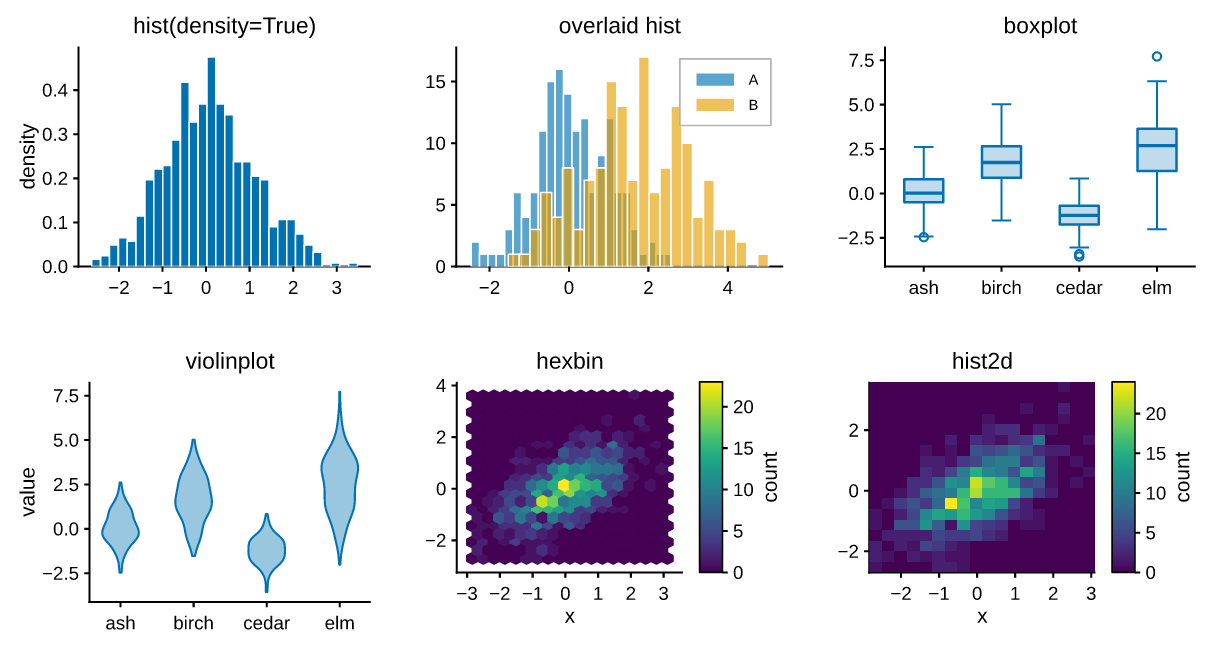

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(580, 310))

axs[0][0].hist(normal, bins=30, density=True)
axs[0][0].set(title="hist(density=True)", ylabel="density")

axs[0][1].hist(groups[0], bins=24, alpha=0.65, label="A")
axs[0][1].hist(groups[1], bins=24, alpha=0.65, label="B")
axs[0][1].set(title="overlaid hist")
axs[0][1].legend(fontsize=7)

positions = [1, 2, 3, 4]
axs[0][2].boxplot(groups, positions=positions)
axs[0][2].set(title="boxplot", xticks=positions, xticklabels=species)

axs[1][0].violinplot(groups, positions=positions)
axs[1][0].set(title="violinplot", xticks=positions, xticklabels=species,
              ylabel="value")

density = axs[1][1].hexbin(cloud_x, cloud_y, gridsize=18)
fig.colorbar(density, label="count")
axs[1][1].set(title="hexbin", xlabel="x")

counts2d = axs[1][2].hist2d(cloud_x, cloud_y, bins=18)
fig.colorbar(counts2d, label="count")
axs[1][2].set(title="hist2d", xlabel="x")

fig

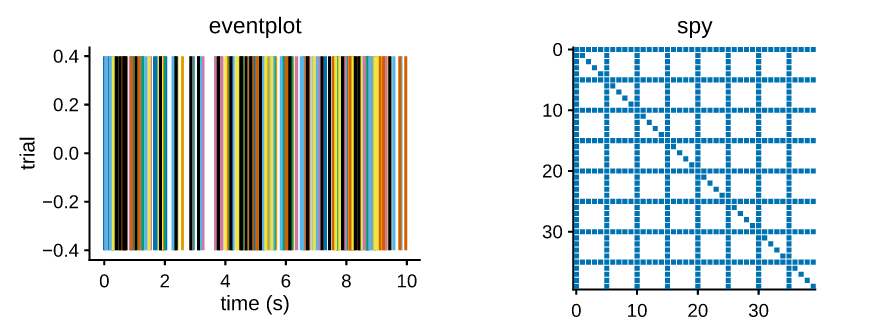

In [5]:
# `eventplot` is the raster plot: one row per trial, a tick per event.
fig, axs = plt.subplots(1, 2, figsize=(430, 160))

trials = [sorted(random.uniform(0, 10) for _ in range(24)) for _ in range(8)]
for row, spikes in enumerate(trials):
    axs[0].eventplot(spikes, lineoffsets=row, linelengths=0.8)
axs[0].set(title="eventplot", xlabel="time (s)", ylabel="trial")

# `spy` shows which entries of a matrix are non-zero, and nothing else.
sparse = [[1 if (i * j) % 5 == 0 or i == j else 0 for j in range(40)]
          for i in range(40)]
axs[1].spy(sparse, markersize=2.5)
axs[1].set(title="spy")

fig

## Scatter

`scatter` takes a size in **`markersize`** — a *diameter in points* — or in
matplotlib's `size=` (an area in pt²) if that is what your script already says.
Passing `c=` a third variable maps it through a colormap and gives you back a
`Mappable` for the colorbar.

The marker set is `"o"`, `"s"`, `"^"`, `"v"`, `"D"`, `"+"` and `"x"`.

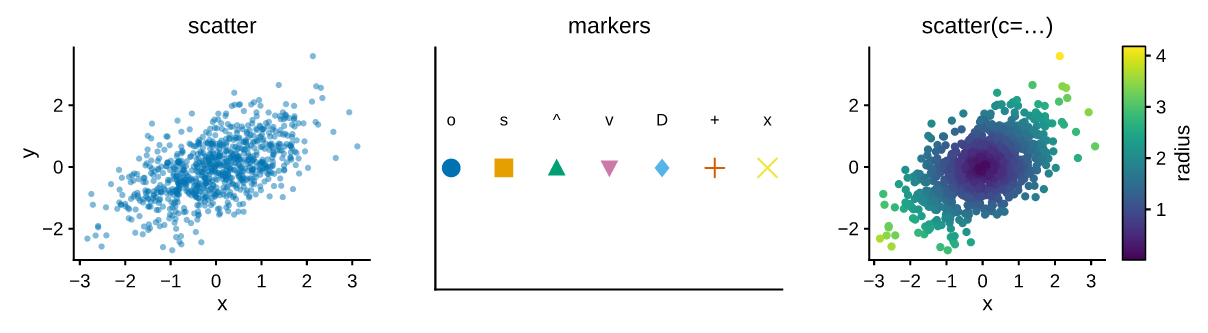

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(580, 160))

axs[0].scatter(cloud_x, cloud_y, markersize=3, alpha=0.5)
axs[0].set(title="scatter", xlabel="x", ylabel="y")

for i, marker in enumerate(["o", "s", "^", "v", "D", "+", "x"]):
    axs[1].scatter([i], [0], marker=marker, markersize=9, color=f"C{i % 8}")
    axs[1].text(i, 0.35, marker, ha="center", fontsize=8)
axs[1].set(title="markers", ylim=(-1, 1), xticks=[], yticks=[])

radius = [math.hypot(x, y) for x, y in zip(cloud_x, cloud_y)]
mapped = axs[2].scatter(cloud_x, cloud_y, c=radius, markersize=4, cmap="viridis")
fig.colorbar(mapped, label="radius")
axs[2].set(title="scatter(c=…)", xlabel="x")

fig

## Uncertainty

`errorbar` draws symmetric `xerr` / `yerr` with caps and a marker by default.
Setting `linestyle="none"` leaves points and whiskers, which is what you want
when a separate `line` is carrying the model.

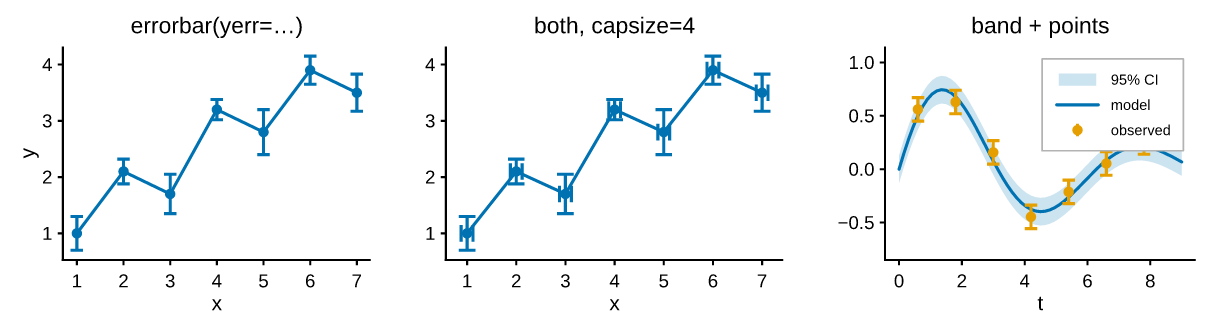

In [7]:
x_obs = list(range(1, 8))
y_obs = [1.0, 2.1, 1.7, 3.2, 2.8, 3.9, 3.5]
y_err = [0.30, 0.22, 0.35, 0.18, 0.40, 0.25, 0.33]
x_err = [0.12] * 7

fig, axs = plt.subplots(1, 3, figsize=(580, 160))

axs[0].errorbar(x_obs, y_obs, yerr=y_err)
axs[0].set(title="errorbar(yerr=…)", xlabel="x", ylabel="y")

axs[1].errorbar(x_obs, y_obs, yerr=y_err, xerr=x_err, capsize=4)
axs[1].set(title="both, capsize=4", xlabel="x")

# The usual publication shape: a fitted model, its confidence band, and the
# measurements it is fitted to, all sharing one color story.
obs_t = [0.6, 1.8, 3.0, 4.2, 5.4, 6.6, 7.8]
obs_y = [math.sin(x) * math.exp(-0.2 * x) + n
         for x, n in zip(obs_t, (0.06, -0.05, 0.08, -0.07, 0.05, -0.03, 0.04))]
obs_err = [0.11] * len(obs_t)

axs[2].fill_between(t, [y - 0.13 for y in damped], [y + 0.13 for y in damped],
                    color="C0", alpha=0.2, label="95% CI")
axs[2].line(t, damped, color="C0", label="model")
axs[2].errorbar(obs_t, obs_y, yerr=obs_err, linestyle="none", color="C1",
                label="observed")
axs[2].set(title="band + points", xlabel="t", ylim=(-0.85, 1.15))
axs[2].legend(fontsize=7, loc="upper right")

fig

## Images and 2D fields

Six ways to show a matrix. `imshow` and `matshow` treat it as pixels;
`pcolormesh` and `pcolor` place it on coordinates you supply; `contour` and
`contourf` trace level sets.

With the default `origin="upper"` row 0 is drawn at the top. Pass
`origin="lower"` for a field sampled on ascending coordinates, and `extent=`
to put it in data units instead of pixel indices.

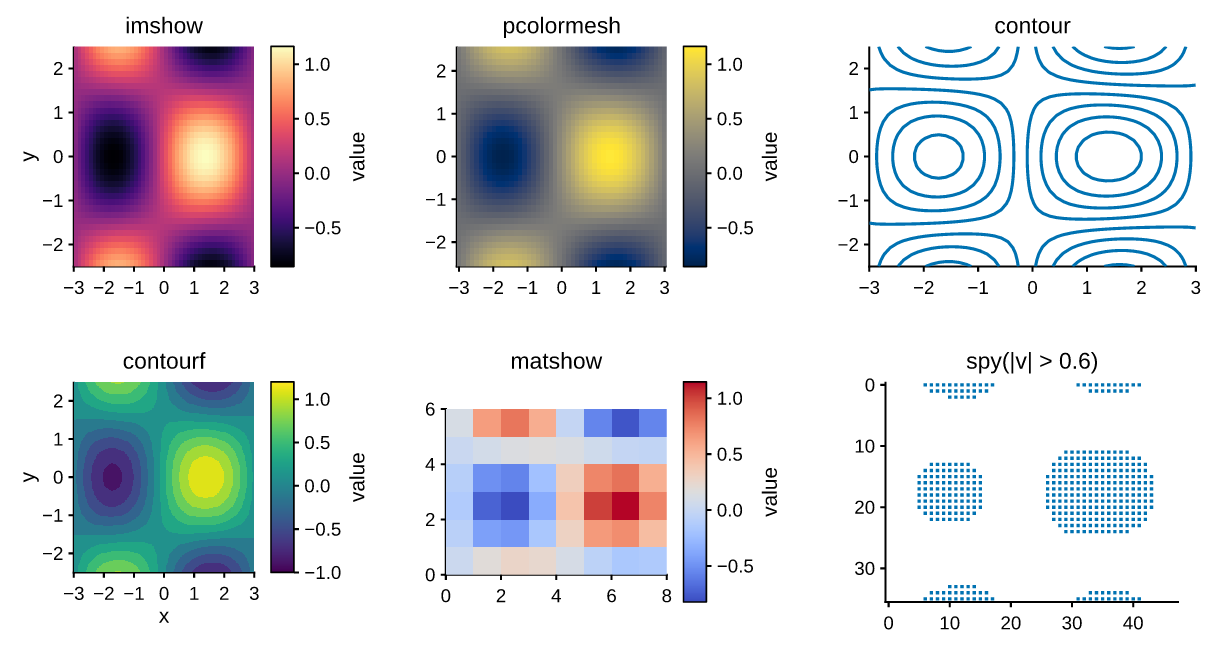

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(580, 310))

image = axs[0][0].imshow(field, cmap="magma", origin="lower",
                         extent=(gx[0], gx[-1], gy[0], gy[-1]))
fig.colorbar(image, label="value")
axs[0][0].set(title="imshow", ylabel="y")

mesh = axs[0][1].pcolormesh(gx, gy, field, cmap="cividis")
fig.colorbar(mesh, label="value")
axs[0][1].set(title="pcolormesh")

axs[0][2].contour(gx, gy, field, levels=9)
axs[0][2].set(title="contour")

filled = axs[1][0].contourf(gx, gy, field, levels=12, cmap="viridis")
fig.colorbar(filled, label="value")
axs[1][0].set(title="contourf", xlabel="x", ylabel="y")

# `matshow` is `imshow` with the conventions of a matrix: square cells, and the
# origin at the top left.
small = [row[::6] for row in field[::6]]
matrix = axs[1][1].matshow(small, cmap="coolwarm")
fig.colorbar(matrix, label="value")
axs[1][1].set(title="matshow")

axs[1][2].spy([[1 if abs(v) > 0.6 else 0 for v in row] for row in field],
              markersize=1.6)
axs[1][2].set(title="spy(|v| > 0.6)")

fig

## Vector fields

`quiver` draws one arrow per sample; `streamplot` integrates the field into
streamlines. Both take `x`, `y`, `u`, `v` with matching shapes — 1D lists or 2D
grids.

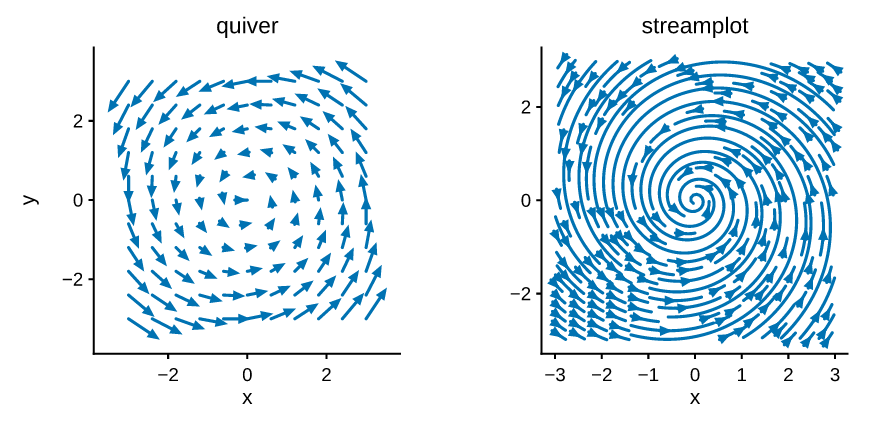

In [9]:
N = 21
vx = [-3.0 + 6.0 * j / (N - 1) for j in range(N)]
vy = [-3.0 + 6.0 * i / (N - 1) for i in range(N)]
# A rotation with a sink: u = -y - 0.2x, v = x - 0.2y.
U = [[-y - 0.2 * x for x in vx] for y in vy]
V = [[x - 0.2 * y for x in vx] for y in vy]

fig, axs = plt.subplots(1, 2, figsize=(430, 205))

step = 2
axs[0].quiver([[x for x in vx[::step]] for _ in vy[::step]],
              [[y] * len(vx[::step]) for y in vy[::step]],
              [row[::step] for row in U[::step]],
              [row[::step] for row in V[::step]],
              scale=0.22)
axs[0].set(title="quiver", xlabel="x", ylabel="y", aspect="equal")

axs[1].streamplot(vx, vy, U, V, density=1.2)
axs[1].set(title="streamplot", xlabel="x", aspect="equal")

fig

## Proportions

`pie` is here for the one case it is right for: a handful of parts of a single
whole. It sets an equal aspect and drops the frame for you.

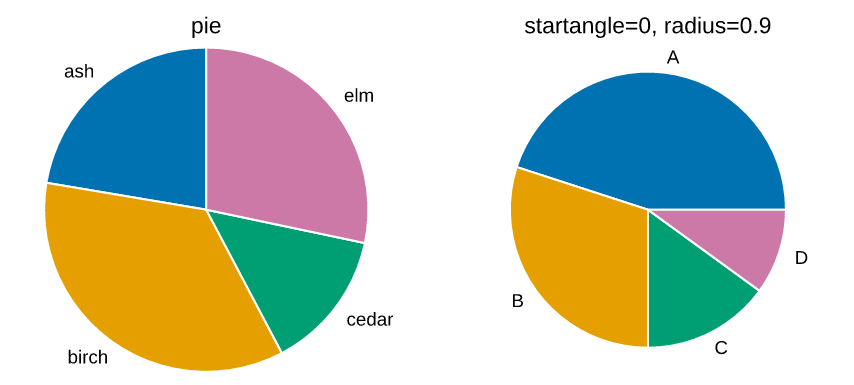

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(410, 185))

axs[0].pie(counts, labels=species)
axs[0].set(title="pie")

axs[1].pie([45, 30, 15, 10], labels=["A", "B", "C", "D"], startangle=0,
           radius=0.9)
axs[1].set(title="startangle=0, radius=0.9")

fig

## Guides, shapes and text

**Guides** span the panel and never affect autoscaling: `axhline`, `axvline`,
`axline`, `axhspan`, `axvspan`. Their data-coordinate siblings — `hlines`,
`vlines` — *are* data and do.

**Shapes** are drawn in data coordinates: `rectangle`, `circle`, `ellipse`,
`polygon`, `fill`, all with `facecolor` / `edgecolor` / `hatch`.

**Text** is `text` at a coordinate and `annotate` for a label with a leader
pointing at one; `arrow` draws a bare arrow from a point along a displacement.

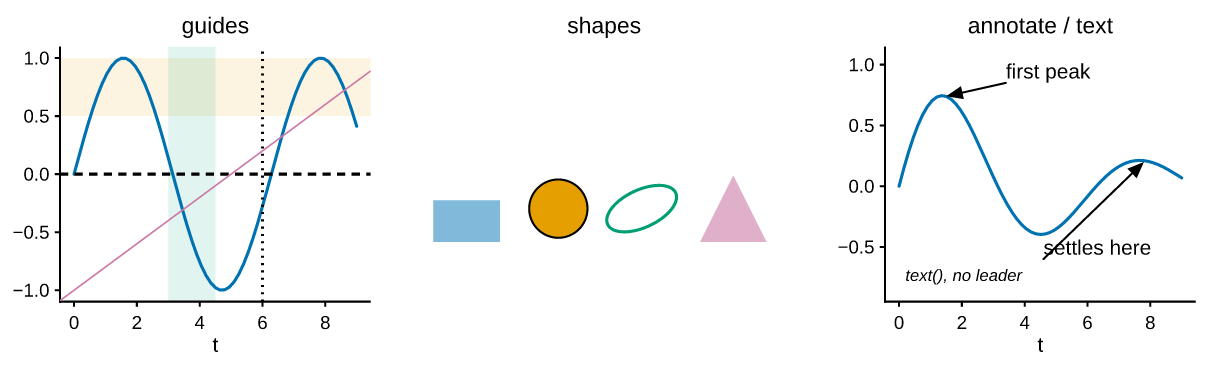

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(580, 180))

axs[0].line(t, wave)
axs[0].axhspan(0.5, 1.0, alpha=0.12, color="C1")     # a band, no autoscale
axs[0].axvspan(3.0, 4.5, alpha=0.12, color="C2")
axs[0].axhline(0.0, linestyle="dashed")
axs[0].axvline(6.0, linestyle="dotted")
axs[0].axline((0, -1), slope=0.2, color="C3", linewidth=0.8)
axs[0].set(title="guides", xlabel="t")

axs[1].rectangle((0.1, 0.1), 0.8, 0.5, facecolor="C0", alpha=0.5)
axs[1].circle((1.6, 0.5), 0.35, facecolor="C1", edgecolor="black")
axs[1].ellipse((2.6, 0.5), 0.9, 0.45, angle=25, fill=False, edgecolor="C2",
               linewidth=1.5)
axs[1].polygon([(3.3, 0.1), (4.1, 0.1), (3.7, 0.9)], facecolor="C3", alpha=0.6)
axs[1].set(title="shapes", xlim=(0, 4.3), ylim=(0, 1.1), aspect="equal")
axs[1].axis("off")          # the frame says nothing about a shape

axs[2].line(t, damped)
axs[2].annotate("first peak", (1.5, 0.74), xytext=(3.4, 0.85))
axs[2].annotate("settles here", (7.8, 0.2), xytext=(4.6, -0.6))
axs[2].text(0.2, -0.78, "text(), no leader", fontsize=8, style="italic")
axs[2].set(title="annotate / text", xlabel="t", ylim=(-0.95, 1.15))

fig

## Polar

`projection="polar"` gives a `PolarAxes`, where the mark is `plot` (there is no
`line`/`plot` ambiguity to resolve) and `set` speaks in `rmax`, `rticks`,
`thetagrids`, `theta_zero_location` and `theta_direction`.

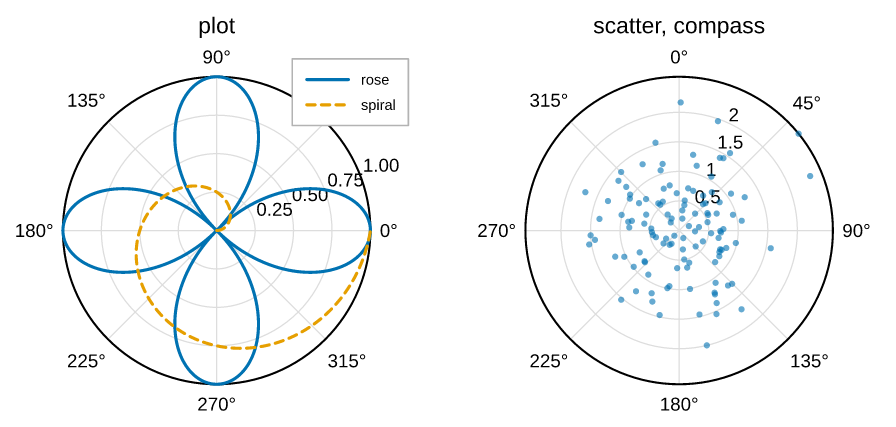

In [12]:
angles = [i * math.pi / 180 for i in range(361)]

fig = plt.figure(figsize=(430, 205))
grid = fig.add_gridspec(1, 2)
left = fig.add_subplot(grid[0, 0], projection="polar")
right = fig.add_subplot(grid[0, 1], projection="polar")

left.plot(angles, [abs(math.cos(2 * a)) for a in angles], label="rose")
left.plot(angles, [a / (2 * math.pi) for a in angles], label="spiral",
          linestyle="dashed")
left.set(title="plot")
left.legend(fontsize=7)

# Compass conventions: zero at the top, clockwise.
bearing = [random.uniform(0, 2 * math.pi) for _ in range(120)]
speed = [random.weibullvariate(1.0, 2.0) for _ in range(120)]
right.scatter(bearing, speed, markersize=3, alpha=0.6)
right.set(title="scatter, compass", theta_zero_location="N", theta_direction=-1,
          rticks=[0.5, 1.0, 1.5, 2.0])

fig

## 3D

`projection="3d"` gives an `Axes3D`. Everything on it projects to **2D vector
paths**, so a surface saved to PDF or SVG stays editable geometry rather than a
rasterized inset — and `save("*.html")` gives an interactive viewer you can spin.

`set(elev=…, azim=…)` moves the camera.

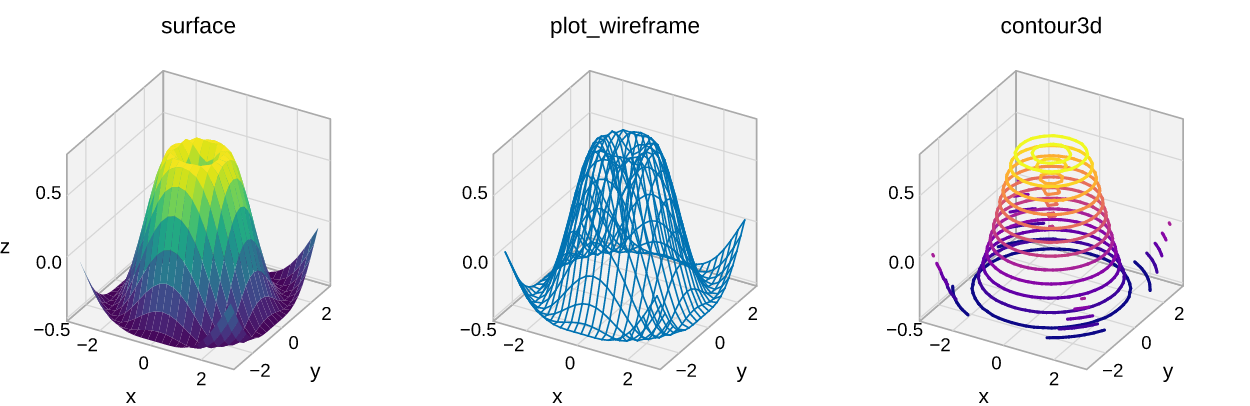

In [13]:
S = 23
sx = [[-3.0 + 6.0 * j / (S - 1) for j in range(S)] for _ in range(S)]
sy = [[-3.0 + 6.0 * i / (S - 1) for _ in range(S)] for i in range(S)]
sz = [[math.sin(math.hypot(x, y) * 1.5) * math.exp(-0.25 * math.hypot(x, y))
       for x, y in zip(rx, ry)] for rx, ry in zip(sx, sy)]

fig, axs = plt.subplots(1, 3, projection="3d", figsize=(600, 195))

axs[0].surface(sx, sy, sz, cmap="viridis")
axs[0].set(title="surface", xlabel="x", ylabel="y", zlabel="z")

axs[1].plot_wireframe(sx, sy, sz)
axs[1].set(title="plot_wireframe", xlabel="x", ylabel="y")

axs[2].contour3d(sx, sy, sz, levels=12, cmap="plasma")
axs[2].set(title="contour3d", xlabel="x", ylabel="y")

fig

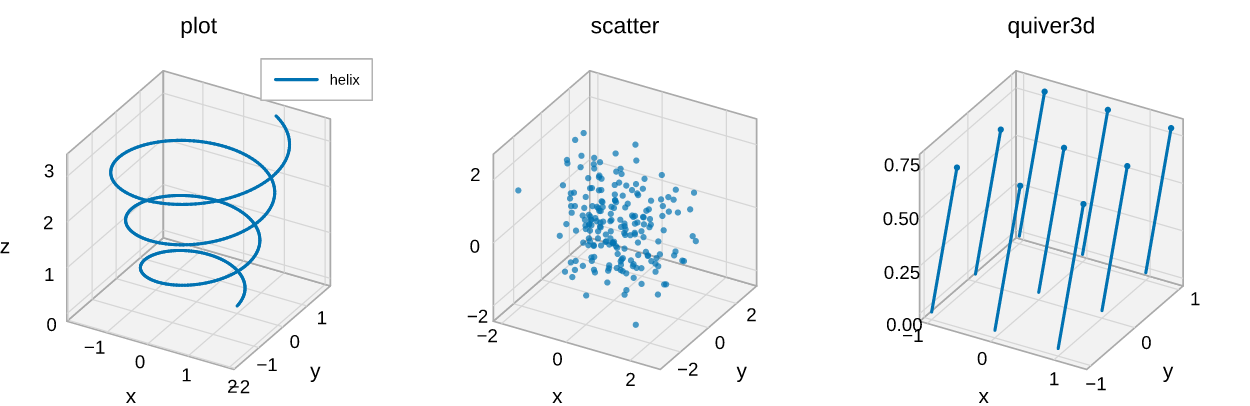

In [14]:
fig, axs = plt.subplots(1, 3, projection="3d", figsize=(600, 195))

turns = [i * 0.05 for i in range(400)]
axs[0].plot([math.cos(a) * (1 + a / 20) for a in turns],
            [math.sin(a) * (1 + a / 20) for a in turns],
            [a / 6 for a in turns], label="helix")
axs[0].set(title="plot", xlabel="x", ylabel="y", zlabel="z")
axs[0].legend(fontsize=7)

n = 200
axs[1].scatter([random.gauss(0, 1) for _ in range(n)],
               [random.gauss(0, 1) for _ in range(n)],
               [random.gauss(0, 1) for _ in range(n)], markersize=3, alpha=0.7)
axs[1].set(title="scatter", xlabel="x", ylabel="y")

qs = [-1.0, 0.0, 1.0]
axs[2].quiver3d([x for x in qs for _ in qs], [y for _ in qs for y in qs],
                [0.0] * 9, [0.4] * 9, [0.0] * 9, [0.8] * 9)
axs[2].set(title="quiver3d", xlabel="x", ylabel="y")

fig

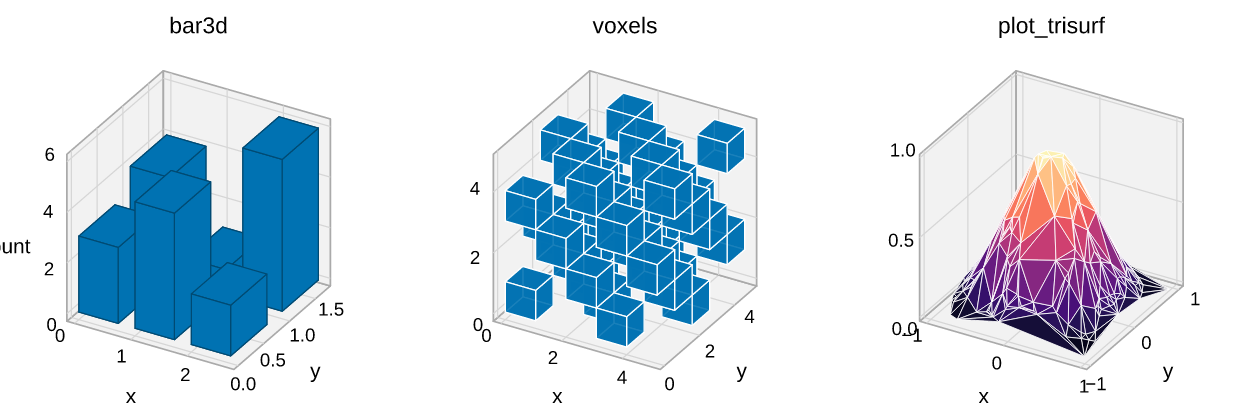

In [15]:
fig, axs = plt.subplots(1, 3, projection="3d", figsize=(600, 195))

bx = [0, 1, 2, 0, 1, 2]
by = [0, 0, 0, 1, 1, 1]
heights = [3, 5, 2, 4, 1, 6]
axs[0].bar3d(bx, by, [0] * 6, [0.7] * 6, [0.7] * 6, heights)
axs[0].set(title="bar3d", xlabel="x", ylabel="y", zlabel="count")

filled = [[[(i + j + k) % 3 == 0 for k in range(5)] for j in range(5)]
          for i in range(5)]
axs[1].voxels(filled, color="C0", edgecolor="white", alpha=0.9)
axs[1].set(title="voxels", xlabel="x", ylabel="y")

m = 220
tx = [random.uniform(-1, 1) for _ in range(m)]
ty = [random.uniform(-1, 1) for _ in range(m)]
tz = [math.exp(-(x * x + y * y) * 2) for x, y in zip(tx, ty)]
axs[2].plot_trisurf(tx, ty, tz, cmap="magma")
axs[2].set(title="plot_trisurf", xlabel="x", ylabel="y")

fig

## Which mark?

| You have | Reach for |
|---|---|
| A signal against time | `line`, or `step` if it holds between samples |
| A value per category | `bar` / `barh` |
| Parts of one whole | `stackplot` over time, `pie` for a handful at one instant |
| One sample of measurements | `hist`, or `stairs` if you binned it yourself |
| Several groups to compare | `boxplot`, or `violinplot` when the shape matters |
| Two variables, few points | `scatter` |
| Two variables, many points | `hexbin` or `hist2d` |
| A third variable per point | `scatter(c=…)` + `colorbar` |
| A matrix of values | `imshow` (pixels) or `pcolormesh` (on coordinates) |
| A smooth field | `contour` / `contourf` |
| A vector field | `quiver` (samples) or `streamplot` (flow) |
| Measurements with uncertainty | `errorbar`, or `fill_between` for a model band |
| Events in time, per trial | `eventplot` |
| Sparsity of a matrix | `spy` |
| A surface over a grid | `surface` (3D) or `contourf` (2D, and usually easier to read) |

**Next:** [layout and composition](04_layout_and_composition.ipynb) — how to
compose these into a figure, restyle them, and choose the colormap.